In [35]:
# CELL 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# CELL 2: Upload dataset ke Colab (ekstrak dulu)
from google.colab import files
uploaded = files.upload()  # Upload file zip hasil download

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# CELL 3: Akses dataset dari Drive
import os
dataset_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Dataset.zip'
print(os.listdir(dataset_path))

['Dataset']


Kelas yang ditemukan: ['Dataset']
Dataset: 2 gambar

Total gambar: 2
                                                path    label
0  /content/drive/MyDrive/SEMESTER 4/KECERDASAN B...  Dataset
1  /content/drive/MyDrive/SEMESTER 4/KECERDASAN B...  Dataset


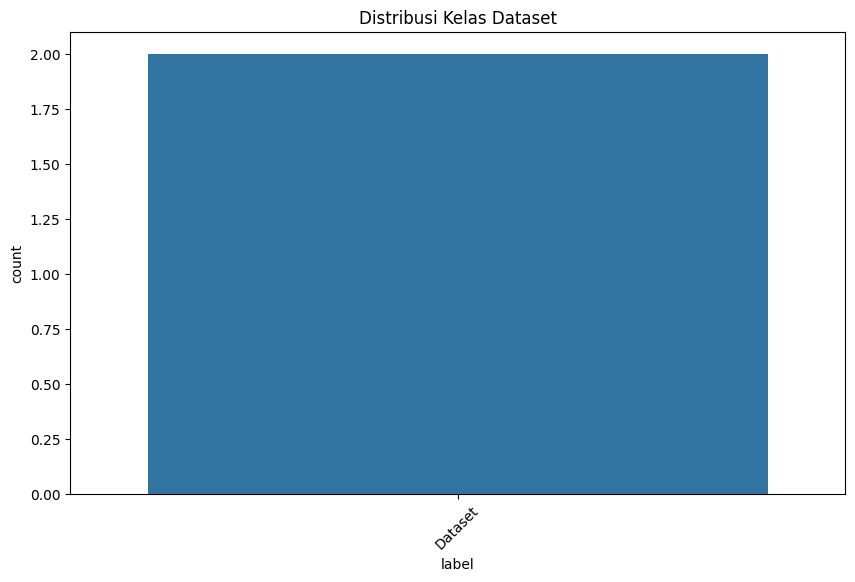

In [37]:
# CELL 4: Eksplorasi dataset
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = '/content/drive/MyDrive/SEMESTER 4/KECERDASAN BUATAN /UAS Kecerdasan Buatan/Dataset.zip'

# Lihat isi folder
classes = os.listdir(dataset_path)
print(f"Kelas yang ditemukan: {classes}")

# Hitung jumlah gambar per kelas
data = []
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    images = os.listdir(class_path)
    print(f"{class_name}: {len(images)} gambar")
    for img in images:
        data.append({
            'path': os.path.join(class_path, img),
            'label': class_name
        })

df = pd.DataFrame(data)
print(f"\nTotal gambar: {len(df)}")
print(df.head())

# Visualisasi distribusi
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='label')
plt.title('Distribusi Kelas Dataset')
plt.xticks(rotation=45)
plt.show()

In [62]:
# ========================================
# CELL 5.5: CEK FILE HASIL EKSTRAKSI
# ========================================

import os

print("🔍 MENCARI FILE extracted_features.csv")
print("="*50)

# Cek di /content/
content_path = '/content/extracted_features.csv'
if os.path.exists(content_path):
    print(f"✅ File ADA di: {content_path}")
    import pandas as pd
    df = pd.read_csv(content_path)
    print(f"   Shape: {df.shape}")
else:
    print(f"❌ File TIDAK ADA di: {content_path}")

# Cek di Drive
drive_path = '/content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan/extracted_features.csv'
if os.path.exists(drive_path):
    print(f"✅ File ADA di: {drive_path}")
    import pandas as pd
    df = pd.read_csv(drive_path)
    print(f"   Shape: {df.shape}")
else:
    print(f"❌ File TIDAK ADA di: {drive_path}")

# Cari semua file .csv di /content/
print("\n🔍 SEMUA FILE .csv DI /content/:")
csv_files = []
for root, dirs, files in os.walk('/content/'):
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            csv_files.append(full_path)
            print(f"   📄 {full_path}")

if len(csv_files) == 0:
    print("   ❌ TIDAK ADA file .csv di /content/")

🔍 MENCARI FILE extracted_features.csv
❌ File TIDAK ADA di: /content/extracted_features.csv
❌ File TIDAK ADA di: /content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan/extracted_features.csv

🔍 SEMUA FILE .csv DI /content/:
   📄 /content/sample_data/california_housing_test.csv
   📄 /content/sample_data/california_housing_train.csv
   📄 /content/sample_data/mnist_train_small.csv
   📄 /content/sample_data/mnist_test.csv


In [63]:
# ---- SIMPAN KE DRIVE (PATH YANG BENAR) ----
save_path = '/content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan/'

# Buat folder jika belum ada
os.makedirs(save_path, exist_ok=True)

# Simpan ke Drive
df_features.to_csv(save_path + 'extracted_features.csv', index=False)
print(f"✅ Fitur disimpan ke Drive: {save_path}extracted_features.csv")

# ***** TAMBAHKAN INI! *****
# Simpan juga ke /content/ (local Colab)
df_features.to_csv('/content/extracted_features.csv', index=False)
print("✅ Backup juga disimpan di /content/extracted_features.csv")

✅ Fitur disimpan ke Drive: /content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan/extracted_features.csv
✅ Backup juga disimpan di /content/extracted_features.csv


In [65]:
# ========================================
# CELL 6: PREPROCESSING (AUTO-DETECT)
# ========================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import pandas as pd
import os

print("🔍 Mencari file extracted_features.csv...")
print("="*50)

# Coba cari di beberapa lokasi
possible_paths = [
    '/content/extracted_features.csv',
    '/content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan/extracted_features.csv',
    '/content/drive/MyDrive/SEMESTER 4/extracted_features.csv',
]

df_features = None
found_path = None

for path in possible_paths:
    if os.path.exists(path):
        df_features = pd.read_csv(path)
        found_path = path
        print(f"✅ File ditemukan di: {path}")
        break

if df_features is None:
    print("❌ File TIDAK DITEMUKAN!")
    print("\nCara mengatasi:")
    print("1. Jalankan CELL 5.5 untuk mencari file")
    print("2. Atau jalankan ulang CELL 5 dengan kode yang sudah diperbaiki")
    raise FileNotFoundError("extracted_features.csv tidak ditemukan!")

print(f"\n📊 Data fitur dimuat: {df_features.shape}")
print(df_features.head())

# ---- PISAHKAN FITUR DAN LABEL ----
X = df_features.drop('label', axis=1).values
y = df_features['label'].values

print(f"\nFitur shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")

# ---- ENCODING LABEL ----
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n📋 Mapping Label:")
for i, label in enumerate(le.classes_):
    print(f"   {i} -> {label}")

# ---- NORMALISASI DATA ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Data setelah normalisasi:")
print(f"   Mean: {X_scaled.mean():.4f}")
print(f"   Std: {X_scaled.std():.4f}")

# ---- SPLIT DATA ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n📂 Split Data:")
print(f"   Training set: {X_train.shape[0]} gambar")
print(f"   Testing set:  {X_test.shape[0]} gambar")

# ---- SIMPAN ----
save_path = '/content/drive/MyDrive/SEMESTER 4/UAS Kecerdasan Buatan'
os.makedirs(save_path, exist_ok=True)

joblib.dump(scaler, save_path + 'scaler.pkl')
joblib.dump(le, save_path + 'label_encoder.pkl')
np.save(save_path + 'X_train.npy', X_train)
np.save(save_path + 'X_test.npy', X_test)
np.save(save_path + 'y_train.npy', y_train)
np.save(save_path + 'y_test.npy', y_test)

# Backup di local
joblib.dump(scaler, '/content/scaler.pkl')
joblib.dump(le, '/content/label_encoder.pkl')
np.save('/content/X_train.npy', X_train)
np.save('/content/X_test.npy', X_test)
np.save('/content/y_train.npy', y_train)
np.save('/content/y_test.npy', y_test)

print(f"\n✅ Preprocessing selesai!")
print(f"   📁 Disimpan di: {save_path}")

🔍 Mencari file extracted_features.csv...
✅ File ditemukan di: /content/extracted_features.csv

📊 Data fitur dimuat: (0, 62)
Empty DataFrame
Columns: [color_0, color_1, color_2, color_3, color_4, color_5, color_6, color_7, color_8, color_9, color_10, color_11, color_12, color_13, color_14, color_15, color_16, color_17, color_18, color_19, color_20, color_21, color_22, color_23, color_24, color_25, color_26, color_27, color_28, color_29, color_30, color_31, color_32, color_33, color_34, color_35, color_36, color_37, color_38, color_39, color_40, color_41, color_42, color_43, color_44, color_45, color_46, color_47, texture_0, texture_1, texture_2, texture_3, texture_4, texture_5, texture_6, texture_7, texture_8, texture_9, area, perimeter, aspect_ratio, label]
Index: []

[0 rows x 62 columns]

Fitur shape: (0, 61)
Label shape: (0,)
Unique labels: []

📋 Mapping Label:


ValueError: Found array with 0 sample(s) (shape=(0, 61)) while a minimum of 1 is required by StandardScaler.